---
<center>

  # **Tarea 03**

**Realizado Por:**

   Samuel Huertas Rojas

---
</center>

# 1.


Considere el problema de frontera
$$

\begin{cases}
u_{xx}(x,y) + u_{yy}(x,y) - u_x(x,y) = f(x,y), & (x,y)\in\Omega,\\[2mm]
u(x,y) = g(x,y), & (x,y)\in \partial\Omega.
\end{cases}

$$


Proponga un esquema de diferencias finitas para este problema que tenga orden de precisión (2,2). 
Escribir de manera explícita cuál es el sistema de ecuaciones lineales que se debe resolver. 

Aproximar la solución $u$ en $\Omega := [0,2]\times[0,3]$, tomando las funciones $f$ y $g$ tales que la solución sea 
$
u(t,x) = e^{-t/2} \sin\left(\frac{\pi}{2}x\right)\cos\left(2x - \frac{\pi}{3}\right).
$

Para tener una buena aproximación de $u_{xx}(x,y)$, $u_{yy}(x,y)$ y $u_{x}(x,y)$, vamos a utilizar los esquemas centrados:

* $ u_{xx}(x,y) \approx \dfrac{V_{m+1, l} - 2 V_{m, l} + V_{m-1, l}}{h_x^2} $ el cual tiene un error de $O(h_x^2)$
* $ u_{yy}(x,y) \approx \dfrac{V_{m, l+1} - 2 V_{m, l} + V_{m, l-1}}{h_y^2} $ el cual tiene un error de $O(h_y^2)$
* $ u_{x}(x,y) \approx \dfrac{V_{m+1,l} - V_{m-1,l}}{2 h_x} $ el cual tienen un error de $O(h_x^2)$

Vamos a realizar una pequeña modificación al PVI:
$$

\begin{cases}
a u_{xx}(x,y) + b u_{yy}(x,y) + c u_x(x,y) = f(x,y), & (x,y)\in\Omega,\\[2mm]
u(x,y) = g(x,y), & (x,y)\in \partial\Omega.
\end{cases}

$$

Donde $a, b, c \in \mathbb{R}$. Con lo que el esquema queda de la forma:

$$
a \dfrac{V_{m+1, l} - 2 V_{m, l} + V_{m-1, l}}{h_x^2} + b \dfrac{V_{m, l+1} - 2 V_{m, l} + V_{m, l-1}}{h_y^2} + c  \dfrac{V_{m+1,l} - V_{m-1,l}}{2 h_x} = f_{m,l}
$$

Siendo $f_{m,l} = f(x_m, y_l)$, multiplicando por $h_x^2h_y^2$, obtenemos:

$$
a h_y^2 V_{m+1, l} - 2 a h_y^2 V_{m, l} + a h_y^2V_{m-1, l} + b h_x^2 V_{m, l+1} - 2b h_x^2 V_{m, l} + b h_x^2 V_{m, l-1} + c\dfrac{h_x h_y^2}{2} V_{m+1,l} - c\dfrac{h_x h_y^2}{2} V_{m-1,l} = h_x^2 h_y^2 f_{m,l}
$$

$$
\left[h_y^2 \left(a + \dfrac{c h_x}{2} \right) \right] V_{m+1, l}  + \left[h_y^2 \left(a - \dfrac{c h_x}{2}\right) \right] V_{m-1, l} + b h_x^2 V_{m, l+1} +b h_x^2 V_{m, l-1} - 2 (b h_x^2 + a h_y^2) V_{m, l}  = h_x^2 h_y^2 f_{m,l}
$$

Llamando $\alpha = h_y^2 \left(a + \dfrac{c h_x}{2} \right)$, $\beta = h_y^2 \left(a - \dfrac{c h_x}{2}\right)$ y $\gamma = b h_x^2 + a h_y^2$ tenemos que:

$$
\alpha V_{m+1, l}  + \beta  V_{m-1, l} + b h_x^2 V_{m, l+1} +b h_x^2 V_{m, l-1} - 2 \gamma V_{m, l}  = h_x^2 h_y^2 f_{m,l}
$$


Mirando para $m=l=1$:

$$
\alpha V_{2, 1}  + \beta  V_{0, 1} + b h_x^2 V_{1, 2} +b h_x^2 V_{1, 0} - 2 \gamma V_{1, 1}  = h_x^2 h_y^2 f_{1,1}
$$

Tenemos que la matriz con $u(x_m, y_l)$ para $m=1,2,3,4$ y $l=1,2,3$ 

$$
\begin{bmatrix}
-2\gamma    & \alpha    & 0         & 0         & bh_x^2    & 0         & 0         & 0         & 0         & 0         & 0         & 0         \\
\beta       & -2\gamma  & \alpha    & 0         & 0         & bh_x^2    & 0         & 0         & 0         & 0         & 0         & 0         \\
0           & \beta     & -2\gamma  & \alpha    & 0         & 0         & bh_x^2    & 0         & 0         & 0         & 0         & 0         \\
0           & 0         & \beta     & -2\gamma  & 0         & 0         & 0         & bh_x^2    & 0         & 0         & 0         & 0         \\
bh_x^2      & 0         & 0         & 0         & -2\gamma  & \alpha    & 0         & 0         & bh_x^2    & 0         & 0         & 0         \\
0           & bh_x^2    & 0         & 0         & \beta     & -2\gamma  & \alpha    & 0         & 0         & bh_x^2    & 0         & 0         \\
0           & 0         & bh_x^2    & 0         & 0         & \beta     & -2\gamma  & \alpha    & 0         & 0         & bh_x^2    & 0         \\
0           & 0         & 0         & bh_x^2    & 0         & 0         & \beta     & -2\gamma  & 0         & 0         & 0         & bh_x^2         \\
0           & 0         & 0         & 0         & bh_x^2    & 0         & 0         & 0         & -2\gamma  & \alpha    & 0         & 0         \\
0           & 0         & 0         & 0         & 0         & bh_x^2    & 0         & 0         & \beta     & -2\gamma  & \alpha    & 0         \\
0           & 0         & 0         & 0         & 0         & 0         & bh_x^2    & 0         & 0         & \beta     & -2\gamma  & \alpha    \\
0           & 0         & 0         & 0         & 0         & 0         & 0         & bh_x^2    & 0         & 0         & \beta     & -2\gamma  \\
\end{bmatrix} \begin{bmatrix}
V_{1,1}\\
V_{2,1}\\
V_{3,1}\\
V_{4,1}\\
V_{1,2}\\
V_{2,2}\\
V_{3,2}\\
V_{4,2}\\
V_{1,3}\\
V_{2,3}\\
V_{3,3}\\
V_{4,3} 
\end{bmatrix} = \begin{bmatrix} \begin{array}{ll}
h_x^2 h_y^2 f_{1,1}  -\beta V_{0,1} - bh_x^2 V_{1,0} \\[3pt]
h_x^2 h_y^2 f_{2,1}  -bh_y^2 V_{1,0} \\[3pt]
h_x^2 h_y^2 f_{3,1}  -bh_x^2 V_{3,0} \\[3pt]
h_x^2 h_y^2 f_{4,1}  -bh_x^2 V_{4,0} - \alpha V_{5,1} \\[3pt]
h_x^2 h_y^2 f_{1,2}  -\beta V_{0,2} \\[3pt]
h_x^2 h_y^2 f_{2,2}  \\[3pt]
h_x^2 h_y^2 f_{3,2}  \\[3pt]
h_x^2 h_y^2 f_{4,2}  -\alpha V_{5,2} \\[3pt]
h_x^2 h_y^2 f_{1,3}  -\beta V_{0,3} - bh_x^2 V_{1,4} \\[3pt]
h_x^2 h_y^2 f_{2,3}  -bh_x^2 V_{2,4} \\[3pt]
h_x^2 h_y^2 f_{3,3}  -bh_x^2 V_{3,4} \\[3pt]
h_x^2 h_y^2 f_{4,3}  -\alpha V_{5,3} - bh_y^2 V_{4,4}
\end{array}\end{bmatrix}
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve
from matplotlib import cm

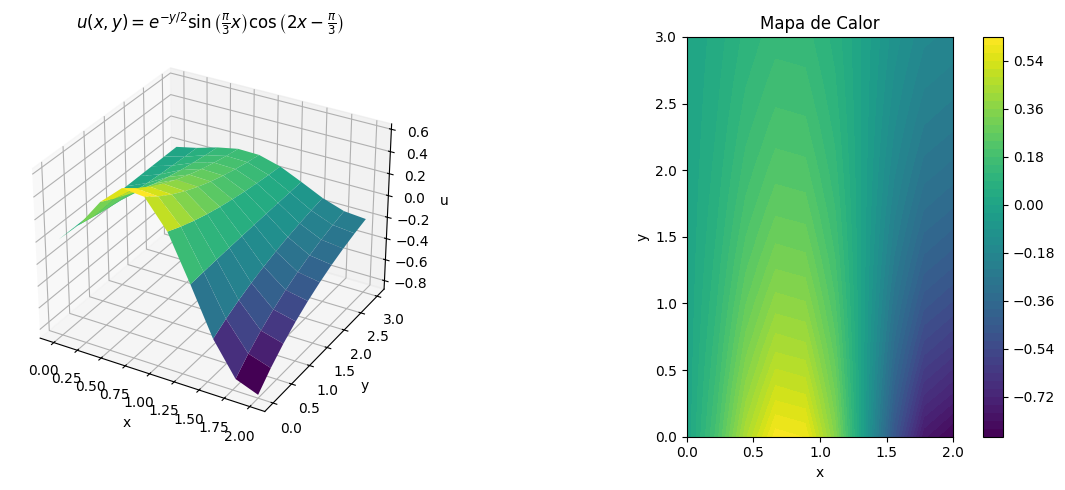

In [3]:
# Definición de la solución exacta
def u(x, y):
    return np.exp(-y/2) * np.sin((np.pi/3) * x) * np.cos(2*x - np.pi/3)

# Rango de la gráfica
x = np.linspace(0, 2, 10)
y = np.linspace(0, 3, 10)
X, Y = np.meshgrid(x, y)

# Evaluación
U = u(X, Y)

# --- Gráfica en 3D ---
fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, U, cmap='viridis')

ax1.set_title(r"$u(x,y)=e^{-y/2}\sin\left(\frac{\pi}{3}x\right)\cos\left(2x-\frac{\pi}{3}\right)$")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("u")

# --- Contorno 2D ---
ax2 = fig.add_subplot(122)
contour = ax2.contourf(X, Y, U, 50, cmap='viridis')
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_title("Mapa de Calor")
ax2.set_aspect("equal")
fig.colorbar(contour, ax=ax2)

plt.tight_layout()
plt.show()



=== Punto del taller ===
Ecuación: u_xx + u_yy - u_x = f(x,y)
Frontera: u(x,y) = g(x,y)

Ensamblando el sistema...
Resolviendo sistema de 1600 ecuaciones...
¡Sistema resuelto exitosamente!


C:\Users\samhu\AppData\Local\Temp\ipykernel_27812\3312679156.py:129: MatrixRankWarning: Matrix is exactly singular
  u = spsolve(A, b)


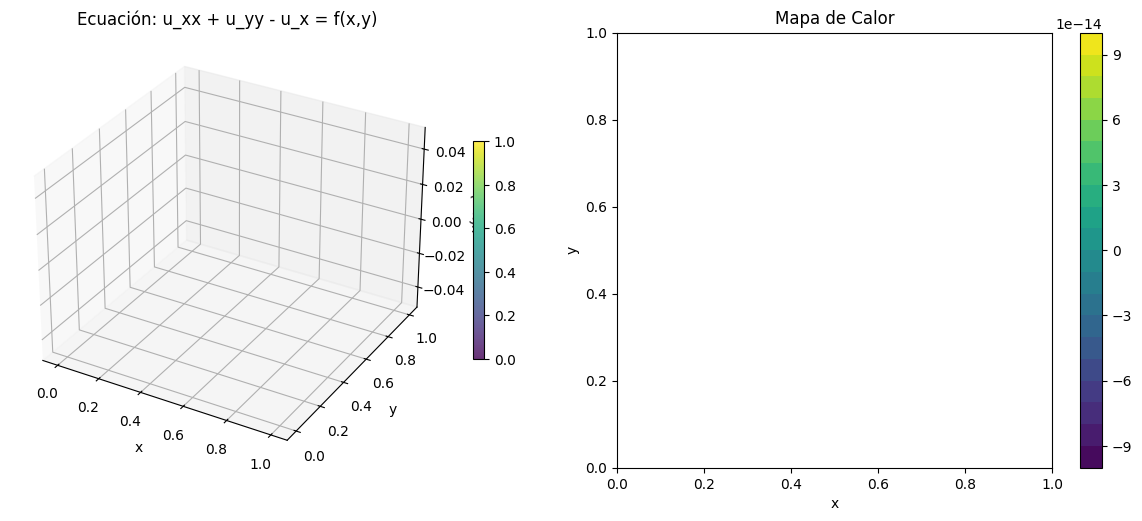

In [ ]:
class EllipticPDESolver:
    """
    Resolvedor de ecuaciones diferenciales elípticas en 2D
    Resuelve: a * u_xx + b *  u_yy - c * u_x = f  en el dominio [0,Lx]×[0,Ly]
    con condiciones de frontera de Dirichlet: u = g en la frontera
    """

    def __init__(self, Lx=2, Ly=3, M=50, N=50):
        """
        Inicializa el dominio y la malla

        Parámetros:
        -----------
        Lx, Ly : float
            Dimensiones del dominio rectangular
        M, N : int
            Número de puntos en dirección x e y
        """
        self.Lx = Lx
        self.Ly = Ly
        self.M = M
        self.N = N

        # Crear malla
        self.x = np.linspace(0, Lx, M)
        self.y = np.linspace(0, Ly, N)
        self.X, self.Y = np.meshgrid(self.x, self.y)

        self.n_nodes = M * N
        self.solution = None

    def set_coefficients(self, a, b, c, f_func):
        """
        Define los coeficientes de la ecuación

        Parámetros:
        -----------
        a:
            Coeficiente que acompaña a u_xx
        b:
            Coeficiente que acompaña a u_yy
        c:
            Coeficiente que acompaña a u_x
        f_func : callable
            Función f(x, y) - término fuente
        """
        self.a = a
        self.b = b
        self.c = c
        self.f_func = f_func

    def set_boundary_conditions(self, g_func):
        """
        Define las condiciones de frontera de Dirichlet

        Parámetros:
        -----------
        g_func : callable
            Función g(x, y) que especifica el valor en la frontera
        """
        self.g_func = g_func

    def assemble_system(self):
        """
        Ensambla la matriz del sistema y el vector del lado derecho
        usando diferencias finitas
        """
        # Inicialización de la matriz A  y el vector b
        A = np.zeros((self.n_nodes, self.n_nodes))
        b = np.zeros(self.n_nodes)

        # Obtengo los valores de las constantes
        a_val = self.a
        b_val = self.b
        c_val = self.c

        hx = self.Lx / self.M
        hy = self.Ly / self.N

        alpha = hy**2 * (a_val + (hx * c_val / 2))
        beta = hy**2 * (a_val - (hx * c_val / 2))
        delta = b_val * hx**2
        gamma = hx**2 * b_val + hy**2 * a_val

        for j in range(self.N):
            for i in range(self.M):
                idx = self.node_index(i, j)
                x, y = self.x[i], self.y[j]
                if i == j:
                    A[i, j]

                if self.is_boundary(i, j):
                    # Condiciones de Dirichlet
                    b[idx] = self.g_func(x, y)

                else:
                    # Ecuación interna
                    A[idx, self.node_index(i + 1, j)] = alpha
                    A[idx, self.node_index(i - 1, j)] = beta
                    A[idx, self.node_index(i, j + 1)] = delta
                    A[idx, self.node_index(i, j - 1)] = delta
                    A[idx, idx] = -gamma

                    # RHS
                    b[idx] = hx**2 * hy**2 * self.f_func(x, y)

            return A.tocsr(), b

    def solve(self):
        """Resuelve el sistema lineal"""
        print("Ensamblando el sistema...")
        A, b = self.assemble_system()

        print(f"Resolviendo sistema de {self.n_nodes} ecuaciones...")
        u = spsolve(A, b)

        # Reorganizar solución en malla 2D
        self.solution = u.reshape((self.N, self.M))
        print("¡Sistema resuelto exitosamente!")

        return self.solution

    def plot_solution(self, title="Solución de la EDP Elíptica"):
        """Grafica la solución"""
        if self.solution is None:
            print("Error: Primero debes resolver el sistema")
            return

        fig = plt.figure(figsize=(12, 5))

        # Gráfica de superficie
        ax1 = fig.add_subplot(121, projection="3d")
        surf = ax1.plot_surface(
            self.X, self.Y, self.solution, cmap=cm.viridis, alpha=0.8
        )
        ax1.set_xlabel("x")
        ax1.set_ylabel("y")
        ax1.set_zlabel("u(x,y)")
        ax1.set_title(title)
        fig.colorbar(surf, ax=ax1, shrink=0.5)

        # Mapa de calor
        ax2 = fig.add_subplot(122)
        contour = ax2.contourf(
            self.X, self.Y, self.solution, levels=20, cmap=cm.viridis
        )
        ax2.set_xlabel("x")
        ax2.set_ylabel("y")
        ax2.set_title("Mapa de Calor")
        ax2.set_aspect("equal")
        fig.colorbar(contour, ax=ax2)

        plt.tight_layout()
        plt.show()


# ==================== USO ====================
def punto1():
    """
    Ecuacion
    a u_xx(x,y) + b u_yy(x,y) - c u_x(x,y)  = f con a(x,y) variable
    """
    print("\n=== Punto del taller ===")
    print("Ecuación: u_xx + u_yy - u_x = f(x,y)")
    print("Frontera: u(x,y) = g(x,y)\n")

    solver = EllipticPDESolver(Lx=1.0, Ly=1.0, M=40, N=40)

    a = 1
    b = 1
    c = 1

    def f(x, y):
        return np.exp(-y / 2) * (
            np.sin((np.pi / 2) * x) * np.cos(2 * x - np.pi / 3) * (np.pi**2 + 1 / 4)
            + np.pi * np.cos((np.pi / 2) * x) * np.sin(2 * x - np.pi / 3)
        )

    def g(x, y):
        return np.exp(-y / 2) * np.sin((np.pi / 2) * x) * np.cos(2 * x - np.pi / 3)

    solver.set_coefficients(a, b, c, f)
    solver.set_boundary_conditions(g)
    solver.solve()
    solver.plot_solution("Ecuación: u_xx + u_yy - u_x = f(x,y)")


punto1()

# 2.

Sea $R := (0,\ell_x)\times(0,\ell_y)$. Considere los problemas de valores iniciales y de frontera:

$$

\boxed{\text{Px}}
\qquad
\left\{
\begin{aligned}
u_t(t,x,y) \;-\; \alpha\, u_{xx}(t,x,y) \;-\; \beta\, u_{yy}(t,x,y) \;+\; \xi\, u_y(t,x,y) &= f(t,x,y), 
& (x,y)\in R,\; t>0, \\[2mm]
u(0,x,y) &= u_0(x,y), 
& 0 \le x \le \ell_x,\ 0 \le y \le \ell_y,\\[2mm]
u(t,x,y) &= g(t,x,y), 
& t>0,\ (x,y)\in \partial R,\\[2mm]
u(t,\ell) + \beta\, u_x(t,\ell) &= g_2(t), 
& t>0.
\end{aligned}
\right.

$$


donde $\alpha, \beta \in \mathbb{R}$ y $f, u_0, g$ son funciones conocidas. Queremos aproximar la solución 
$u(t,x,y)$ para valores de $(x,y) \in \overline{R}$ y $t \in [0,T]$. 

Plantee el esquema de ADI–Crank–Nicolson para aproximar la solución $u$ de 
$\boxed{\text{Px}}$.  
Escribir de manera explícita cuál es el sistema de ecuaciones lineales que se debe resolver en cada paso.


# 3.

Demuestre que $\left( H^{2}(\Omega), (v,w)_{2,\Omega} \right)$ es un espacio de Hilbert, 
siendo $\Omega := (a,b)\subseteq \mathbb{R}$.

Tenemo que $H^{2}(\Omega)$ es un espacio de Sobolev el cual:

$$
H^{2}(\Omega) := \{ v \in L^2(\Omega)/ v', v'' \in L^2(\Omega) \}
$$

Con producto interno $(v,w)_{H^2(\Omega)} := (v,w)_{L^2(\Omega)} + (v',w')_{L^2(\Omega)} + (v'',w'')_{L^2(\Omega)}$ y $(v,w)_{L^2(\Omega)} := \int_{\Omega}vw$

Para demostrar que $H^2{\Omega}$ es un E.H. este debe de ser completo. Definiendo una ${f_m}$ un sucesion de Cauchy en el espacio $H^2{\Omega}$. Esto es:

$$
\exists f \in H^2{\Omega}: ||f_m - f||_{H^2{\Omega}} \longrightarrow 0
$$

Fijando un $\epsilon > 0$ talque ${f_m}$ es una sucesión de Cahcy $\exists N(\epsilon) \in \mathbb{N}$ talque $||f_m - f_p||_{H^2{\Omega}} < \epsilon$   $\forall m, p \geq N(\epsilon)$



Tenemos que:

$$
\|f_{m} - f_{p}\|_{H^2(\Omega)}  = 
\left( \|f_{m} - f_{p}\|_{L^2(\Omega)} ^2 
+ \|f'_{m} - f'_{p}\|_{L^2(\Omega)} ^2 
+ \|f''_{m} - f''_{p}\|_{L^2(\Omega)} ^2 \right)^{1/2} < \epsilon
$$

En particular:
* $ \|f_{m} - f_{p}\|_{L^2(\Omega)} \leq \|f_{m} - f_{p}\|_{H^2(\Omega)} < \epsilon $
* $ \|f'_{m} - f'_{p}\|_{L^2(\Omega)} \leq \|f_{m} - f_{p}\|_{H^2(\Omega)} < \epsilon $
* $ \|f''_{m} - f''_{p}\|_{L^2(\Omega)} \leq \|f_{m} - f_{p}\|_{H^2(\Omega)} < \epsilon $

Se sigue que ${f_m}$, ${f'_m}$ y ${f''_m}$ son sucesiones de Cauchy en $L^2(\Omega)$. Como $L^2(\Omega)$ es una E.H. $\exists g, h, l \in $L^2(\Omega)$ tales que:

* $ \|f_{m} - g\|_{L^2(\Omega)} \longrightarrow 0 $
* $ \|f'_{m} - h\|_{L^2(\Omega)} \longrightarrow 0 $
* $ \|f''_{m} - l\|_{L^2(\Omega)} \longrightarrow 0 $


Afirmamos que $g' = h$ y $g''= l$ en sentido debil de las distribuciones o sea que $h$ y $l$ son las derivadas debiles de $g$. Sea $\varphi \in C_0^{\infty}(\Omega)$, Tenemos que:

$$
\int_{\Omega} g \varphi' - \int_{\Omega} f_m \varphi' = \int_{\Omega} (g - f_m) \varphi'
$$

Por $|(u,v)| \leq \| u \| \| v \|$ tenemos que:

$$
\left| \int_{\Omega} (g - f_m) \varphi' \right| \leq \| g - f_m\|_{L^2\Omega} \| \varphi'\| _{L^2\Omega} \longrightarrow 0 
$$

Cuando $m \longrightarrow \infty$. Tenemos que:

$$
\int_\Omega g \varphi' = \lim_{m \to \infty} \int_\Omega f_m \varphi'
$$

De forma similar:

$$
\left| \int_{\Omega} h \varphi  - \int_{\Omega} f_m \varphi \right| = \left| \int_{\Omega} (h - f_m) \varphi \right| \leq \| h - f_m\|_{L^2\Omega} \| \varphi\| _{L^2\Omega} \longrightarrow 0 
$$

Cuando $m \longrightarrow \infty$. Tenemos que:

$$
\int_\Omega h \varphi = \lim_{m \to \infty} \int_\Omega f_m \varphi
$$

Asi: 


$$
\int_\Omega g \varphi' = \lim_{m \to \infty} \int_\Omega f_m \varphi' = - \lim_{m \to \infty} \int_\Omega f_m \varphi = - \int_\Omega h \varphi
$$

Ahora mirando $\|f''_{m} - l\|_{L^2(\Omega)}$ tenemos que $\varphi \in C_0^{\infty}(\Omega)$:

$$
\left| \int_{\Omega} (g - f_m) \varphi'' \right| \leq \| g - f_m\|_{L^2\Omega} \| \varphi''\| _{L^2\Omega} \longrightarrow 0 
$$

Cuando $m \longrightarrow \infty$. Tenemos que: 

$$
\int_\Omega g \varphi'' = \lim_{m \to \infty} \int_\Omega f_m \varphi''
$$

De forma similar con $l$ se tiene que:

$$
\left| \int_{\Omega} l \varphi  - \int_{\Omega} f_m \varphi \right| = \left| \int_{\Omega} (l - f_m) \varphi \right| \leq \| l - f_m\|_{L^2\Omega} \| \varphi\| _{L^2\Omega} \longrightarrow 0 
$$

Cuando $m \longrightarrow \infty$. Tenemos que:

$$
\int_\Omega l \varphi = \lim_{m \to \infty} \int_\Omega f_m \varphi
$$

Así:

$$
\int_\Omega g \varphi'' = \lim_{m \to \infty} \int_\Omega f_m \varphi'' = \lim_{m \to \infty} \int_\Omega f_m \varphi = \int_\Omega l \varphi
$$

Vemos que tanto $ \| f_m - f\| < \epsilon $. Por lo que la serie de Cauchy $\{f_m\}$ converge en $H^{2}(\Omega)$. Podemos concluir que $(H^2(\Omega), (.,.)_{2,\Omega})$ es un espacio de Hilbert.

# 4.

Sea $u(x)=x^{\alpha}$, con $\alpha \in \mathbb{R}$, y consideremos $\Omega := (0,1)$.  
¿Para qué valores de $\alpha$ se garantiza que $u \in L^{2}(\Omega)$?  


Tenemos que $L^2(\Omega) = \{ \varphi : \Omega \mapsto \mathbb{R} / \varphi \text{ es medible y } \int_{\Omega} |\varphi|^2 < \infty \} $

Para que $u(x) \in L^2(\Omega)$, $u$ tiene que ser medible y que $\int_{\Omega} |u|^2 < \infty$, siendo $\Omega := (0,1)$, tenemos que analizar primero cuando la integral $(1)$ converge:

$$
\int_0^1 x^a dx \tag{1}
$$

Para analizar cuando la integral $(1)$ converge, tenemos que analizar los siguientes dos casos, el primero cuando $a \neq -1$ y el segundo cuando $a = -1$

* Mirando el caso cuando $a \neq -1$, tenemos que:
$$
\lim_{b \to 0^{+}} \int_b^1 x^a dx = \lim_{b \to 0^{+}}  \dfrac{1}{a + 1}  \left[x^{a+1} \right]_{x=b}^{x=a} = \lim_{b \to 0^{+}}  \dfrac{1}{a + 1}  \left[1 - b^{a+1} \right] = \lim_{b \to 0^{+}}  \dfrac{1}{a + 1}  - \dfrac{1}{a + 1} b^{a+1} 
$$

Tenemos que:
$$
\lim_{b \to 0^{+}}  \dfrac{1}{a + 1} b^{a+1} 
$$

Va a ser convergente si y solo si $a + 1 > 0$ con lo que $a > -1$

* Para el caso que $a = -1$, se tiene que:

$$
\lim_{b \to 0^{+}} \int_b^1 x^{-1} dx = \lim_{b \to 0^{+}} \left[ ln|x| \right]_{x = b}^{x = 1} = \lim_{b \to 0^{+}} \left[ ln|1| - ln|b| \right] =  - \lim_{b \to 0^{+}} ln(b) \longrightarrow \infty 
$$

Tenemos que cuando $a = -1$ la integral $(1)$ va a ser divergente.

$$
\therefore  \int_0^1 x^a dx 
$$

Converge caundo $a > -1$

Regresando a nuestra integral de $u(x)$, tenemos que:

$$
\int_0^1 |u(x)|^2 dx = \int_0^1 |x^{\alpha}|^2 dx = \int_0^1 x^{2 \alpha} dx 
$$

Vemos que la integral converge cuando $2 \alpha > -1$, con lo que $\alpha > -\frac{1}{2}$

$\therefore$ $u(x) = x^{\alpha} \in L^2(\Omega)$ cuando $\alpha > - \frac{1}{2}$

Tambien es importante aclarar que la función $u(x)$ es medible en $\Omega$

¿Para cuáles se tiene $u \in H^{1}(\Omega)$?

Definiendo $H^1(\Omega)$:

$$
H^1(\Omega) := \{ f \in L^{2}(\Omega) / f' \in L^{2}(\Omega)  \}
$$

Como se demostro previamente $u \in L^{2}(\Omega)$ cuando $\alpha > -\frac{1}{2}$, ahora tenemos que encontrar la derivada debil $u'(x)$ y ver si está pertenece a $ L^{2}(\Omega)$, la derivada debil de $u(x)$ va a estar dada por:

$$
\int_{\Omega} u \varphi' = - \int_{\Omega} l \varphi
$$

Siendo $\varphi \in C_{0}^{\infty}$, $l$ es la derivada debil. Mirando el lado izquierdo tenemos:

$$
\int_{\Omega}u \varphi' = \int_0^1 x^{\alpha} \varphi'(x) dx
$$

Realizando  la integración por partes tenmos que 
$$
\left[ x^{\alpha} \varphi(x) \right]_{x=0}^{x=1} - \int_{0}^{1} \alpha x^{\alpha + 1} \varphi(x) dx
$$

Mirando los valores cuando $x \longrightarrow 0^{+}$:

* Para $\alpha > 0$:

$$
\lim_{b \to 0^{+}} \left[ 1^{\alpha} \varphi(1) - (b)^{\alpha} \varphi(b) \right] - \int_{b}^{1} \alpha x^{\alpha + 1} \varphi(x) dx 
$$

Como $\varphi \in C_{0}^{\infty}$, entonces $\varphi(1) = \varphi(0) = 0$

$$
\lim_{b \to 0^{+}} - \int_{b}^{1} \alpha x^{\alpha + 1} \varphi(x) dx = - \int_{0}^{1} \alpha x^{\alpha + 1} \varphi(x) dx = - \int_{\Omega} \alpha x^{\alpha + 1} \varphi(x) dx
$$

Tenemos que la derivada debil es $l = \alpha x^{\alpha + 1}$, vamos a demostrar que $l \in L^{2}(\Omega)$

$$
\int_{0}^{1} |\alpha x^{\alpha + 1}|^{2}  dx = \int_{0}^{1} \alpha x^{2(\alpha + 1)}  dx
$$

Tenemos que la integral converge cuandp $2(\alpha + 1) > -1$ lo que nos da que $l \in L^{2}(\Omega)$ cuando $\alpha > 1/2$

* Para $\alpha = 0$:

$$
\left[ x^{0} \varphi(x) \right]_{x=0}^{x=1} - \int_{0}^{1} 0 dx = - \int_{0}^{1} 0 dx  = 0 
$$

Tenemos que $l = 0$ por lo que cuando $\alpha = 0$ la función $u(x)$ no tiene derivada debil.

* Para $\alpha < 0$:

$$
\lim_{b \to 0^{+}} \left[ 1^{\alpha} \varphi(1) - (b)^{\alpha} \varphi(b) \right] - \int_{b}^{1} \alpha x^{\alpha + 1} \varphi(x) dx = \lim_{b \to 0^{+}} \left[ - (b)^{\alpha} \varphi(b)  - \int_{b}^{1} \alpha x^{\alpha + 1} \varphi(x) dx \right]
$$

Vemos este limite va a ser indeterminado por lo que cuando $\alpha < 0$ la función $u(x)$ no va a tener derivada debil.

Por lo tanto $u(x) = x^{\alpha} \in H^1(\Omega)$ cuando $\alpha > 1/2$


# 5.

Considere el problema con valores en la frontera

$$

\left\{
\begin{aligned}
- u''(x) + q(x)\,u'(x) + r(x)\,u(x) &= f(x), \qquad x \in \Omega := (a,b), \\[2mm]
u(a) &= 0, \\[1mm]
u(b) &= 0,
\end{aligned}
\right.

$$

con $f \in L^{2}(\Omega)$, $q \in C^{1}(\overline{\Omega})$, $r \in C(\overline{\Omega})$ donde $q$ y $r$ verifican $
r - \tfrac{1}{2} q' \ge 0 \quad \text{en } \Omega.
$

* Plantee la formulación variacional asociada al problema.

* Demuestre que la formulación variacional tiene solución única.

Ayuda: Demuestre que  

$$

\int_{\Omega} q\, v\, v' = -\tfrac{1}{2} \int_{\Omega} q'\, v^{2}
\quad \text{para toda } v \in H^{1}_{0}(\Omega)

$$

(emplee un argumento de densidad y el hecho de que   $(\psi^{2})' = 2\psi \psi'$, $\forall\, \psi \in C^{\infty}_{0}(\Omega)$).

Para plantear la formulación variacional, se observa que los valores en la frontera tienen condiciones de tipo Dirichelet con lo cual nuestro espacio vectorial va a ser:

$$
H_0^1(\Omega) := \{ f \in H^1(\Omega) / f(a) = 0, f(b) = 0 \}
$$

Tomando una funcion $\varphi \in C_0^\infty(\Omega)$, tenemos que:

$$
- u''(x) \varphi(x) + q(x)u'(x)\varphi(x) + r(x)u(x)\varphi(x) = f(x)\varphi(x)
$$

Realizando la integral sobre $\Omega$:

$$
- \int_\Omega u''(x) \varphi(x) dx + \int_\Omega q(x)u'(x)\varphi(x) dx + \int_\Omega r(x)u(x)\varphi(x) dx  = \int_\Omega f(x)\varphi(x) dx
$$


Realizando la primera integral de la izquierda:

$$
- \int_a^b u''(x) \varphi(x) dx = - \left[ \varphi(x) u'(x) \right]_{x=a}^{x=b} + \int_a^b u'(x) \varphi'(x) dx = - \varphi(b) u'(b) + \varphi(a) u'(a) + \int_a^b u'(x) \varphi'(x) dx
$$

Como  $\varphi \in C_0^\infty(\Omega)$ vemos que $\varphi(b) = \varphi(a) = 0$, con lo que nos queda: 

$$
\int_a^b u'(x) \varphi'(x) dx
$$


Con la segunda integral del lado izquierdo, recordemos que $q \in C^1(\overline{\Omega})$:

$$
\int_\Omega q(x)u'(x)\varphi(x) dx = \left[ u(x) q(x) \varphi(x) \right]_{x=a}^{x=b} - \int_a^b u(x) \left[ q'(x) \varphi(x) + q(x) \varphi'(x) \right] dx = u(b) q(b) \varphi(b) - u(a) q(a) \varphi(a) - \int_a^b u(x) q'(x) \varphi(x)  dx - \int_a^b u(x) q(x) \varphi'(x)  dx
$$

Como $q \in C^1(\overline{\Omega})$ y $\varphi \ in C_0^\infty(\Omega)$ en donde $\varphi(b) = \varphi(a) = 0$, tenemos que:

$$
- \int_a^b u(x) q'(x) \varphi(x)  dx - \int_a^b u(x) q(x) \varphi'(x)  dx
$$

Lo que nos queda:

$$
\int_\Omega u'(x) \varphi'(x) dx - \int_\Omega u(x) q'(x) \varphi(x)  dx - \int_\Omega u(x) q(x) \varphi'(x)  dx + \int_\Omega r(x)u(x)\varphi(x) dx  = \int_\Omega f(x)\varphi(x) dx
$$

Vemos que obtuvimos la formulación variacional del problema de valores en la frontera como: 

Hallar $u \in H_0^1(\Omega)$ talque: 

$$
a(u,v) = F(v)
$$


Donde: 

$$
a(u,v) = \int_\Omega u' v' - \int_\Omega u q' v - \int_\Omega u q v'  dx + \int_\Omega r u v= \int_\Omega f vdx
$$

$$
F(v) = \int_\Omega fv
$$

Para demostrar que la formulación variacional tiene solución única se debe de cumplir el teorema de Lax-Milgram, el cual dice que: Sea $h$ un E.H. y $a: H\times H \mapsto \mathbb{R}$ una forma bilineal, continua y coersiva entonces $\forall F \in H' : \exists! u \in H $ talque $a(u,v) = F(v) \forall v \in H$.

Vamos a mirar $F(v)$ es lineal y acotado:

* Linealidad:

$$
F(\alpha v + w) = \int_\Omega f(\alpha v + w) =  \alpha \int_\Omega fv + \int_\Omega fw = \alpha F(v) + F(w)
$$

* Acotada:

$$
|F(v)| = |\int_\Omega fv| \leq \|f\|_{L^2(\Omega)} \|v\|_{L^2(\Omega)} \leq M  \|v\|_{H^1(\Omega)}
$$

Vamos a mirar si $a$ es bilineal, continua y coersiva:

* Bilineal:

$$

$$